# MATH70105 – Project

## Tactical Analysis in Football
---
Student = Andrea Calzavara

CID = 06035601

Acknowledgement: All core analysis and implementation have been carried out independently.

---

### Table of Contents

<details open>
<summary><b>1. Introduction</b></summary>

- [1.1 Motivation](#sec1-1)
- [1.2 Database Description](#sec1-2)
- [1.3 Dataset and Package Loading](#sec1-3)

</details>

<details>
<summary><b>2. Graph Representation of a Football Match</b></summary>

- [2.1 Player-Based Passing Graph](#sec2-1)
- [2.2 Position-Based Passing Graph](#sec2-2)
- [2.3 Passing Heat Map](#sec2-3)

</details>

<details>
<summary><b>3. Single Match Analysis</b></summary>

- [3.1 Key Graph-Theoretical Features](#sec3-1)
- [3.2 Stochastic Block Models](#sec3-2)
- [3.3 Passing Motifs](#sec3-3)

</details>

<details>
<summary><b>4. Multi-Match Analysis: Graph Embeddings</b></summary>

- [4.1 Feature Representation](#sec4-1)
- [4.2 Graph2Vec](#sec4-2)
- [4.3 Graph Attention Autoencoder (GATE)](#sec4-3)

</details>

<details>
<summary><b>5. References</b></summary>

- [References](#sec5-1)

</details>

#### 1. Introduction

#### <a id="1-1"></a> 1.1 Motivation

Football is one of the most widely played and analysed sports worldwide. Recent advances in event and tracking technologies have enabled the collection of large-scale datasets describing player actions, ball movements, and team interactions throughout a match. As a result, data-driven approaches have become increasingly important for performance analysis, tactical evaluation, and strategic decision-making.

While traditional football statistics provide valuable insights into individual and team performance, they often fail to capture the complex interaction patterns that emerge during a match. Football is inherently a networked system, where players continuously interact through passing sequences, positional structures, and collective tactical behaviours.

Graph theory provides a natural framework for modelling these interactions. By representing players or sections of the pitch as nodes and passes as edges, football matches can be analysed as dynamic networks, allowing the investigation of connectivity, centrality, block structures, and other hidden characteristics that are difficult to observe using conventional statistics or the match results.

The aim is to develop a structured framework for football tactical analysis by combining graph theory, and graph representation learning techniques. Through the study of passing networks, this work seeks to provide a quantitative perspective on team organisation and tactical behaviour at both the single-match and multi-match levels.

##### <a id="sec1-2"></a> 1.2 Data Base Description

This study uses the publicly available **StatsBomb Open Data** repository, which provides detailed event-level information for professional football matches. The dataset contains comprehensive information on competitions, matches, team line-ups, and in-game events, including passes, shots, carries, interceptions, and defensive actions. Each event is associated with spatial coordinates, timestamps, player identifiers, and contextual metadata, enabling a detailed reconstruction of match dynamics.

The analysis carried on this document focuses on the **2023/24 Bundesliga season**, using all league matches played by **Bayer 04 Leverkusen**. Match-level information includes participating teams, match date, competition, final score, and additional contextual variables.

To construct the passing networks, only **successful passes** were retained. Each pass event contains information on the passer, recipient, start and end locations, pass length, pass angle, and pass outcome. These attributes allow the creation of detailed representations of player interactions throughout a match.

Passing networks are modelled as **directed weighted graphs**, where nodes represent players (or pitch zones in the positional analysis) and directed edges represent completed passes. Edge weights correspond to the frequency of passes exchanged between two nodes during a match. Player positions are estimated using the average spatial coordinates of their passing actions, enabling the visualisation of team structure based on observed behaviour rather than nominal formations.

The high spatial and temporal resolution of the StatsBomb dataset makes it particularly suitable for network-based analysis. The availability of player identities, pass recipients, timestamps, and pitch coordinates enables the construction of rich passing networks that capture both the structural organisation and the dynamic behaviour of football teams.

Following preprocessing, successful pass events are aggregated at the match level to generate a directed weighted graph for each match. These graphs form the basis for the network analysis, graph embedding methods, and machine learning models developed throughout this analysis.

https://github.com/statsbomb/open-data/blob/master/README.md

##### <a id="sec1-3"></a> 1.3 Data set and packages uploading

In [ ]:
#import necessary packages

from statsbombpy import sb
import mplsoccer
from mplsoccer import Pitch
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from networkx.algorithms.community import kernighan_lin_bisection
from networkx.algorithms.community import modularity
from networkx.algorithms.community import girvan_newman
import random
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from networkx.algorithms.triads import triadic_census
from collections import defaultdict
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.manifold import TSNE
import os
os.environ['KERAS_BACKEND']='tensorflow'
import keras
import tensorflow as tf
from keras.layers import Layer, Dense, Reshape
from keras.models import Model
import plotly.graph_objects as go

c:\Users\8andr\OneDrive\Desktop\Imperial_College_University\VS_Code\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
# run the setup notebook
%run zz_Project_code_Setup_v01.ipynb

In [3]:
#Example of competition data set
competitions = sb.competitions()
competitions.head(2)

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-11-15T23:17:41.827093,2025-11-15T23:17:41.827093,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381


### 2. Graph Representation of a Football Match

This chapter introduces the graph-based representation of a football match and illustrates how passing interactions can be modelled as networks. The analysis focuses on the Bundesliga 2023/24 match between **Bayer 04 Leverkusen** and **Werder Bremen**, which concluded with a 5–0 victory for Bayer Leverkusen. This match serves as a case study for demonstrating the proposed network analysis framework.
The objective of this chapter is to explore alternative graph representations of football matches and evaluate how each representation captures different aspects of team organisation and tactical behaviour.

        Section 2.1: Player-Based Passing Network - this representation focuses on player interactions.
                - Nodes correspond to individual players.
                - Directed edges represent successful passes between players.
                - Self-loops are not permitted, as a player cannot pass the ball to themselves.
        Section 2.2: Position-Based Passing Network - this representation reflects the spatial ball movement
                - Nodes correspond to predefined pitch zones.
                - Directed edges represent passes between zones.
                - Self-loops are permitted, representing passes that both originate and terminate within the same area of the pitch
        Section 2.3: Passing Heat Maps - the final representation uses spatial heat maps derived from passing events

Highlights of the game are available HERE (https://www.youtube.com/watch?v=UbDHze0tkRU - freeYouTube video), while the main match statistics can be found on the ESPN website HERE (https://www.espn.co.uk/football/match/_/gameId/677837/werder-bremen-bayer-leverkusen)

In [4]:
# set the parameters
competition_id = 9 #: Bundensliga
season_id=281 # : 2023/24 season

# collection of all the matches of that competition
matches = sb.matches(competition_id=competition_id,season_id=season_id)
matches.head(2)

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,...,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,3895292,2024-04-06,15:30:00.000,Germany - 1. Bundesliga,2023/2024,Union Berlin,Bayer Leverkusen,0,1,available,...,2025-07-06T04:26:07.636270,28,Regular Season,Stadion An der Alten Försterei,Benjamin Brand,Nenad Bjelica,Xabier Alonso Olano,1.1.0,2,2
1,3895320,2024-04-27,19:30:00.000,Germany - 1. Bundesliga,2023/2024,Bayer Leverkusen,VfB Stuttgart,2,2,available,...,2025-01-02T11:05:23.462823,31,Regular Season,BayArena,Felix Zwayer,Xabier Alonso Olano,Sebastian Hoeneß,1.1.0,2,2


In [5]:
#Select a specific match for the analysis
match_id = 3895302 #: Bayer Leverkusen vs Werder Bremer 
team_id = 904

team_name = 'Bayer Leverkusen'

home_team = matches.loc[matches['match_id']==match_id]['home_team'].values[0]
away_team = matches.loc[matches['match_id']==match_id]['away_team'].values[0]

matches[matches['match_id']==match_id]

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,...,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
6,3895302,2024-04-14,17:30:00.000,Germany - 1. Bundesliga,2023/2024,Bayer Leverkusen,Werder Bremen,5,0,available,...,2024-06-25T09:20:17.324346,29,Regular Season,BayArena,Harm Osmers,Xabier Alonso Olano,Ole Werner,1.1.0,2,2


In [6]:
# selection of the events/match

events = sb.events(match_id=match_id)

events.head(2)

,50_50,bad_behaviour_card,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_save_block,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,...,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 3421, 'lineup': [{'player': {'id...",Bayer Leverkusen,904,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 352, 'lineup': [{'player': {'id'...",Werder Bremen,176,00:00:00.000,Starting XI,NaN


In [7]:
# in events['type'] there is the information of the event that has been observed during the match. For our analysis the information about Pass is our main scope
events['type'].unique()

array(['Starting XI', 'Half Start', 'Pass', 'Ball Receipt*', 'Carry',
       'Pressure', 'Miscontrol', 'Dribble', 'Duel', 'Interception',
       'Ball Recovery', 'Dispossessed', 'Block', 'Foul Committed',
       'Foul Won', 'Error', 'Shot', 'Goal Keeper', 'Injury Stoppage',
       'Referee Ball-Drop', '50/50', 'Clearance', 'Offside',
       'Dribbled Past', 'Player Off', 'Player On', 'Half End',
       'Substitution', 'Bad Behaviour', 'Tactical Shift', 'Shield'],
      dtype=object)

In [8]:
#filter the match events database with only passing details
passes_team_match = create_passes_db(events=events,team_id=team_id)

passes_team_match.head(2)

,50_50,bad_behaviour_card,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_save_block,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,...,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Bayer Leverkusen,904,00:00:19.820,Pass,NaN
16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Bayer Leverkusen,904,00:00:23.749,Pass,NaN


##### <a id='sec2-1'></a> 2.1 Player-based pass graph

In [9]:
# Generation of the graph

G_team_match_dist = G_dist_gen(passes=passes_team_match)

# Generation of the average  players position
pos_team_match = player_position(passes=passes_team_match)

#retriving the xG stats for the match and the team
xg_team_match = events[(events['team_id'] == team_id)]['shot_statsbomb_xg'].dropna().sum()

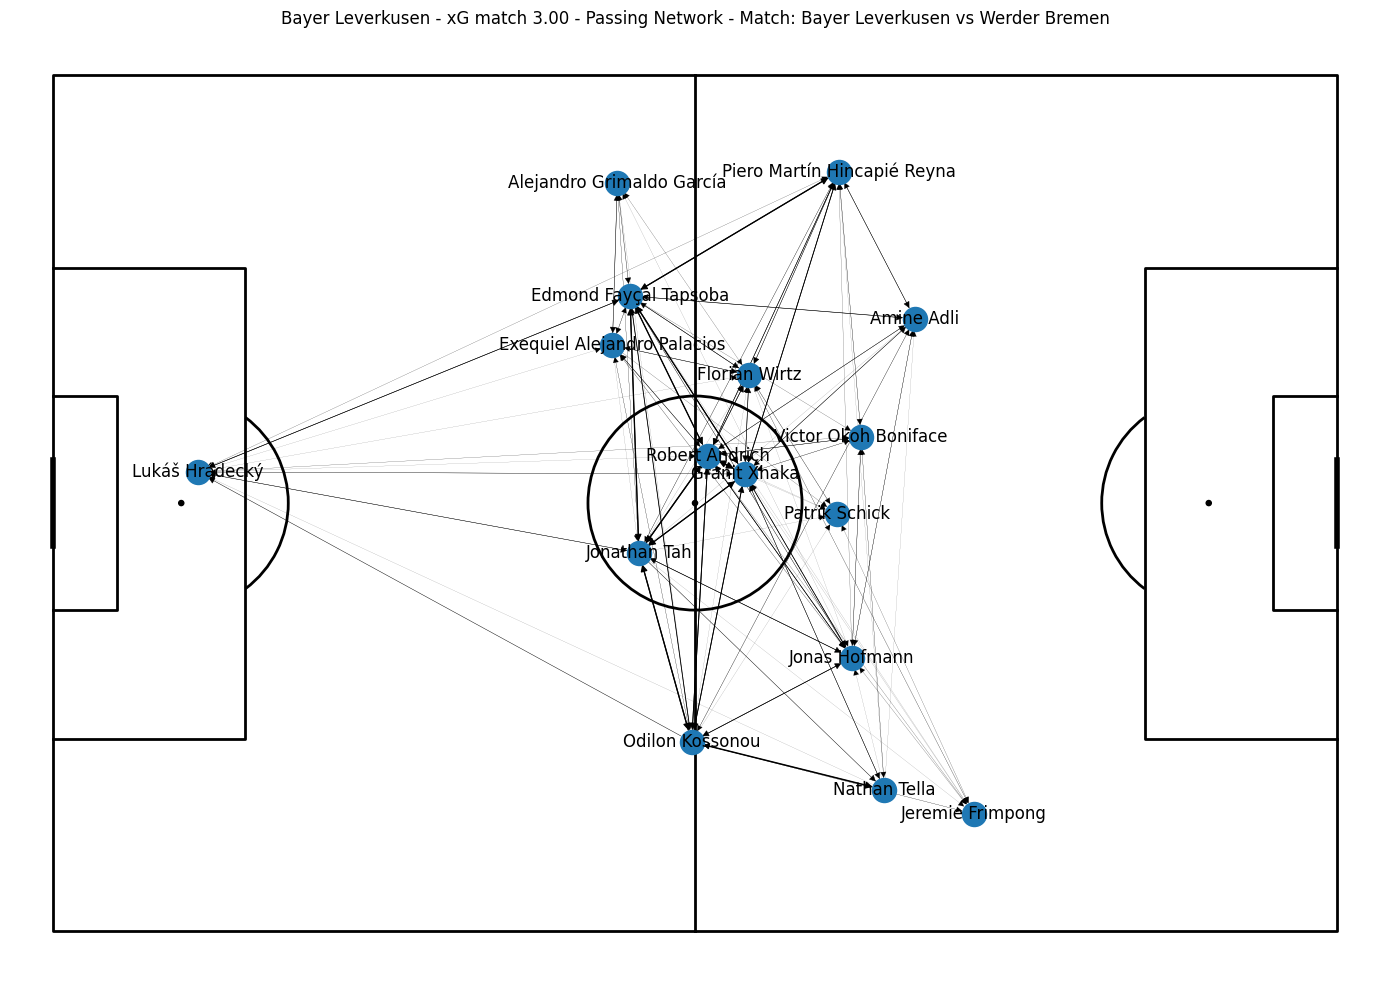

In [10]:
#plot of the player positional
pitch = Pitch(
    pitch_type="statsbomb",
    pitch_color="white",
    line_color="black"
)

fig, ax = pitch.draw(figsize=(14, 12))
nx.draw(
    G_team_match_dist, pos_team_match,
    node_size=300,
    width=[(1/G_team_match_dist[u][v]['weight'])/15 for u, v in G_team_match_dist.edges()],
    with_labels=True
)
plt.title(f"{team_name} - xG match {xg_team_match:.2f} - Passing Network - Match: {home_team} vs {away_team}")
plt.show()

The position of the players and the network of passes reflects the offensive style of the team. The mass majority of the team players are sitting on the offensive side of the pitch and the most qualitative players (with the highest betweeness of centrality - Andrich, Xhaka and Wirtz) are in the midfield position. To notice how Boniface (striker) has an average position less advanced than other players due to his role as pivot and receiver of the passes from the team in order to redirect the game.

##### <a id='sec2-2'></a> [2.2.](#sec2-2) Positional-based pass graphs

One of the possible issues on the player passing network is related to the substitution, the change of scheme during the match and possible red card, that affect the structure of the graph through the time. The solution the we are proposing is to based the node on the section of the pitch rather than to the players, to fix the position and study the structure of the relationship based on areas. Since the section is meaninful also on the attaching strategy but can have a self pass, the self loops are presents and have remarkable meaning. Passess done trhough sectors vertically are more meaninful that horizontal passes. This observation could be developed further in a future analysis.

For the positional pass graph we have divided the pitch in 12 sections with an equal area (as per below pictures) to define portion of the pitch that are identify as node

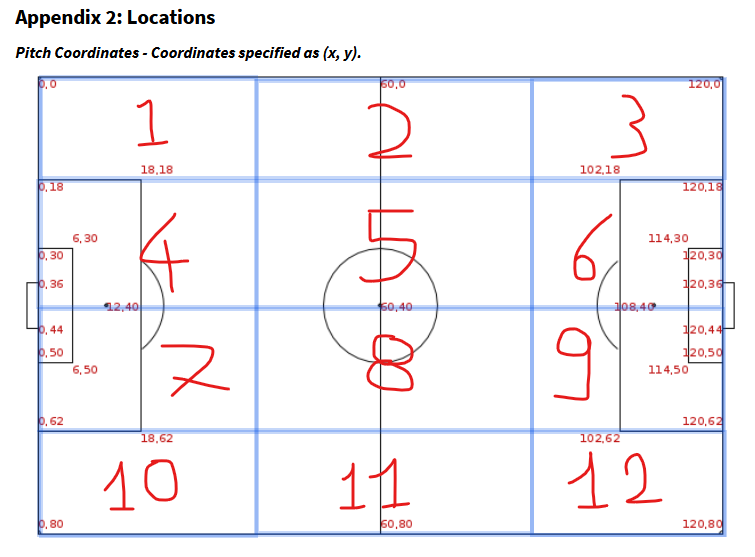

In [11]:
# in passes data frame there are the details of the location of the player passing the ball and receiving
passes_team_match[['player','pass_recipient','location','pass_end_location']].head(2)

,player,pass_recipient,location,pass_end_location
15,Nathan Tella,Lukáš Hrádecký,"[33.3, 43.2]","[8.5, 33.8]"
16,Lukáš Hrádecký,Edmond Fayçal Tapsoba,"[8.5, 33.8]","[15.1, 21.5]"


In [12]:
# Generation of the graph
G_team_match_sec = G_section_gen(passes=passes_team_match)
# Generation of the average  section position
sec_team_match = section_position(passes=passes_team_match)

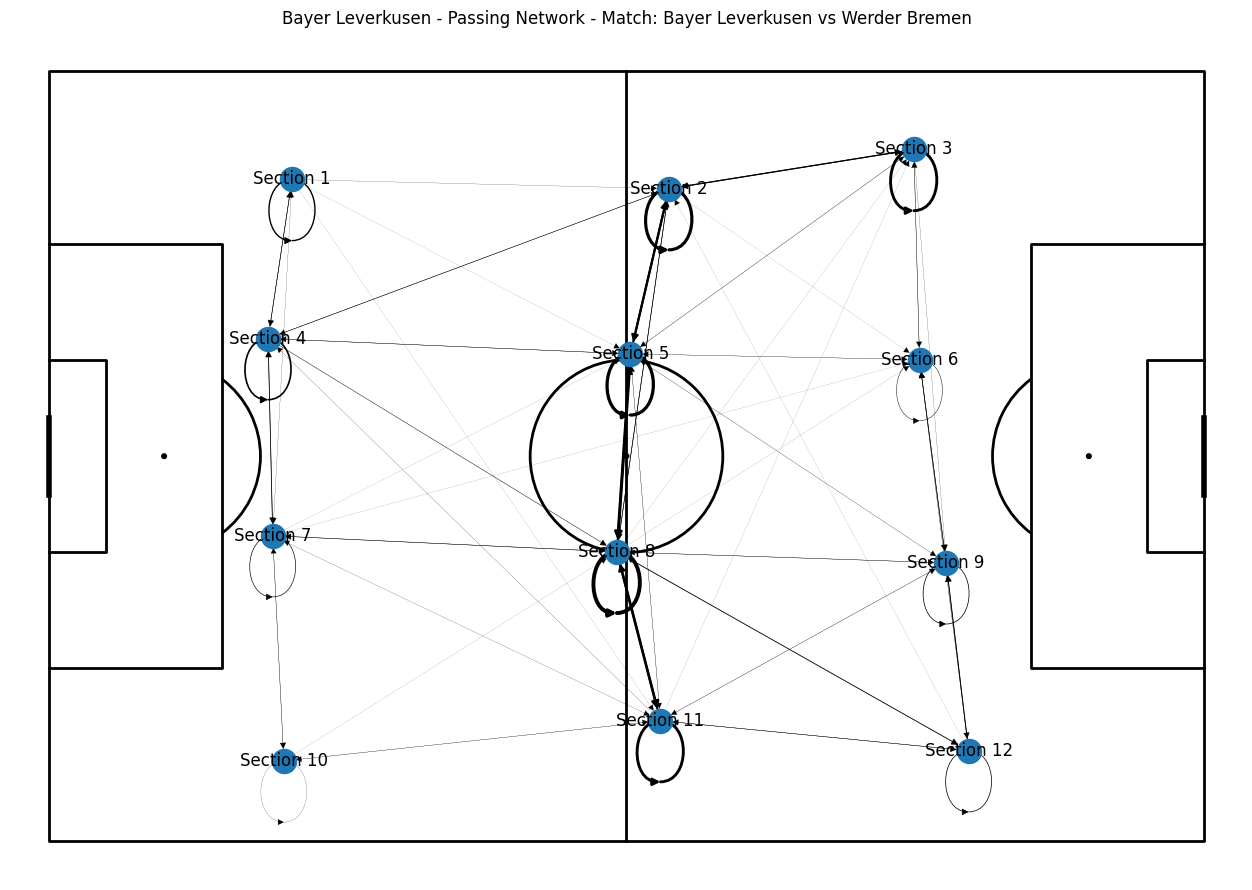

In [13]:
#Plot of the section based graph
pitch = Pitch(
    pitch_type="statsbomb",
    pitch_color="white",
    line_color="black"
)

fig, ax = pitch.draw(figsize=(14, 9))

nx.draw(
    G_team_match_sec, sec_team_match,
    node_size=300,
    width=[(1/G_team_match_sec[u][v]['weight'])/15 for u, v in G_team_match_sec.edges()],
    with_labels=True
)
plt.title(f"{team_name} - Passing Network - Match: {home_team} vs {away_team}")
plt.show()

From the chart is evident as self loops represents a core factor and description of the section. To noticed as well how the pass intensity results more evident on the right side of the pitch with increasing density of passes.

#### <a id='sec2-3'></a> [2.3.](#sec2-3) Passing Heat Map


Heat maps provide a visual summary of passing activity across the pitch, highlighting frequently used areas, spatial concentration of possession, and attacking tendencies that may not be immediately apparent from network visualisations alone.

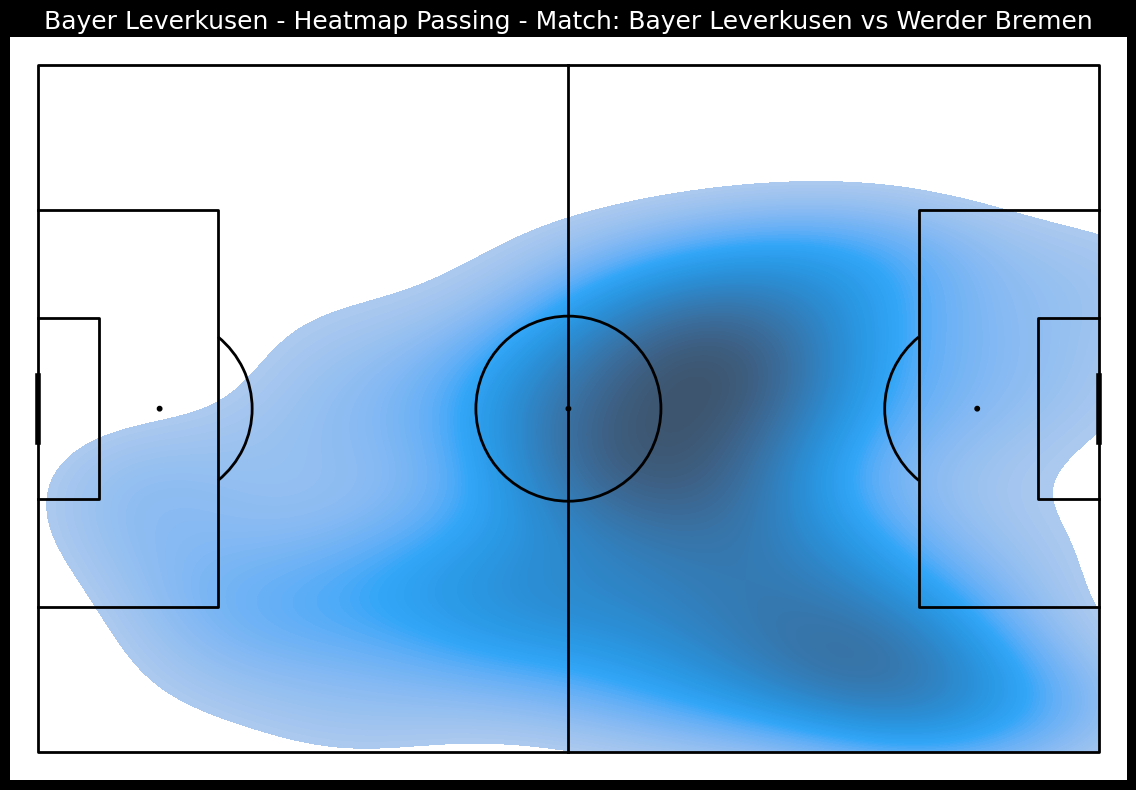

In [14]:
#Heatmaps representation of the match
filtered_events = passes_team_match

x_start = [
    loc[0] for loc in filtered_events['location']
    if isinstance(loc, list) and len(loc) == 2 and not np.isnan(loc[0])
]

y_start = [
    loc[1] for loc in filtered_events['location']
    if isinstance(loc, list) and len(loc) == 2 and not np.isnan(loc[1])
]

pitch = mplsoccer.Pitch(pitch_type='opta', pitch_color='white',line_color='black', line_zorder=2)
fig, ax= pitch.draw(figsize = (16,8))
fig.set_facecolor('black')

pitch.kdeplot(x_start, y_start, ax=ax, fill=True, n_levels=100)
ax.set_title(f"{team_name} - Heatmap Passing - Match: {home_team} vs {away_team}", fontsize=18, color="white")
plt.show()

### <a id='ch3'></a> [3.](#ch3) Single Match Analysis

This chapter is dedicated to the analysis of a single match exploring some mathematical information starting from the graph applied to the football match, giving a possible meaning on the example we are studying.

        In Section 3.1 will be presented some features based on graph theory
        In Section 3.2 we will explore the Stochastic Block Model tecnique (SBM) to find pattern/blocks for the graph with possible tactically meaning in the match
        In Section 3.3 will be presented a dynamic analysis based on triads and how could be used to understand the tactics of formations

#### <a id='sec3-1'></a> [3.1.](#sec3-1) Key Graph-Theoretical Features

##### Key Graph-Theoretical Metrics Used in the Analysis

Based on Hamilton et al. [1] the key metrics performed are listed below with a possible tactical interpretation (we have used players as node for the description of the tactical meaning but it could be extended for all the possible interpretation of the nodes - for example sections of the pitch)

| Metric | Possible Interpretation in Football | Formula | Expected Tactical Meaning |
|----------|----------|----------|----------|
| **Density** | Possession | $D = \frac{2m}{n(n-1)}$ | Higher values indicate that passes are distributed among many players, and collective involvement. Lower values may indicate a more direct passes style of play with less "tiki-taka" and more counter attach style. |
| **Average Degree** | Player involvement | $\bar{k} = \frac{1}{n}\sum_{i=1}^{n} k_i$ | Similarly to density, higher values suggest that players are more interconnected and actively involved in the passing network. Lower values may suggest limited participation or fragmented play. |
| **Centralization** | Dependence on key players | $C = \frac{\sum_{i=1}^{n}(k_{\max}-k_i)}{(n-1)(n-2)}$ | It is the signal for player centrality. High centralization indicates dependency on a small number of players to control possession and distribute the ball. Low centralization suggests a more balanced team structure. |
| **Clustering Coefficient** | Local play structure and passing triangles | $C = \frac{1}{n}\sum_{i=1}^{n}\frac{2e_i}{k_i(k_i-1)}$ | Triangles are known as key football play style. Higher values indicate frequent triangular passing patterns hence a strong local combinations. Lower values may suggest a more direct or vertical play style (counter attack for example). |
| **Modularity** | Presence of tactical subgroups / communities | $Q = \frac{1}{2m}\sum_{i,j}\left(A_{ij}-\frac{k_i k_j}{2m}\right)\delta(c_i,c_j)$ | High modularity suggests distinct tactical units (e.g., defence, midfield, attack) interacting more within groups than between groups. Low modularity indicates a more integrated team structure. |
| **Average Shortest Path Length** | Ball circulation efficiency | $L = \frac{1}{n(n-1)}\sum_{i\neq j} d(i,j)$ | It indicates the speed of the ball circulation and how it can reach some players in a low number of passes. Lower values indicate that the ball can move efficiently between players through fewer passing connections. Higher values may indicate slower circulation or structural bottlenecks. |
| **Betweenness Variance** | Concentration of playmaking responsibility | $\mathrm{Var}(BC)$, where $BC$ denotes node betweenness centrality | High variance indicates that a few players dominate the flow of possession (key playmakers). Low variance suggests a more evenly distributed passing responsibility. |
| **Algebraic Connectivity** | Network robustness and resilience | $\lambda_2(L)$ (second-smallest eigenvalue of the graph Laplacian) | Higher values indicate a more cohesive and resilient network that remains connected even if key players are removed. Lower values suggest greater vulnerability to disruptions. This can detect if any substitution or red card can affect the structure of the play |
| **Assortativity** | Similar nodes connect together | $C = \frac{\sum_{i,j}ij(e_{ij}-q_iq_j)}{\sigma^2_q}$ | Higher values indicate a more interaction among players. Lower values suggest hubs distribute to peripheral area. if one player or more act as a playmakers (low value) or if their a collective control of the ball |

Notation

- $n$ = number of nodes (players)
- $m$ = number of edges (passing connections)
- $k_i$ = degree of node $i$
- $k_{\max}$ = maximum degree in the network
- $e_i$ = number of connections among the neighbours of node $i$
- $A_{ij}$ = adjacency matrix entry between nodes $i$ and $j$
- $c_i$ = community membership of node $i$
- $\delta(c_i,c_j)$ = indicator function equal to 1 if nodes belong to the same community and 0 otherwise
- $d(i,j)$ = shortest-path distance between nodes $i$ and $j$
- $L$ = graph Laplacian matrix
- $\lambda_2$ = second-smallest eigenvalue of the Laplacian matrix

In [15]:
metrics_G_match_team_dist = graph_level_metrics(G = G_team_match_dist)

metrics_G_match_team_sec = graph_level_metrics(G = G_team_match_sec)

In [ ]:
#conver the metrics in a pd.DataFrame
metrics_G_match_team_dist_pd = pd.DataFrame(metrics_G_match_team_dist, index=[0]).T.rename(columns={0: "value"})[:12]
metrics_G_match_team_sec_pd = pd.DataFrame(metrics_G_match_team_sec, index=[0]).T.rename(columns={0: "value"})[:12]

metrics_G_match_team_dist_pd.columns = ["player_graph"]
metrics_G_match_team_sec_pd.columns = ["section_graph"]

comparison_metrics = pd.concat(
    [metrics_G_match_team_dist_pd, metrics_G_match_team_sec_pd],
    axis=1
)
comparison_metrics

,player_graph,section_graph
number_of_players,16.000000,12.000000
number_of_edges,136.000000,77.000000
num_passes,584.000000,584.000000
density,0.566667,0.583333
average_degree,17.000000,12.833333
degree_centralization,0.533333,0.563636
average_clustering,0.786977,0.704299
modularity,0.175801,0.221880
number_of_communities,3.000000,3.000000
average_path_length,2.353507,2.607484


#### <a id='sec3-2'></a> [3.2.](#sec3-2) Stochastic Block Models

The Stochastic Block Model (SBM) is one of the most important probabilistic models in network science, with we can try to observe network structure explained by hidden groups of nodes

In this chapter we will frame the model with:

        - nodes = players/section
        - edges = passes
        - groups = tactical roles / functional structures / latent tactical communities

The SBM verts on the assumption that the probability of a pass between two players depends mainly on the groups they belong to.

The Stochastic Block Model (SBM) represents the passing network as a probabilistic generative process in which players belong to latent tactical groups. The probability of a pass between two players depends on the interaction intensity between the groups to which they belong. Unlike traditional community detection approaches based solely on edge density, the SBM can capture a broader range of tactical structures, including hierarchical organization, core-periphery systems, and transition-oriented patterns. [2]

To account for heterogeneous player involvement, a Degree-Corrected Stochastic Block Model (DC-SBM) was adopted. This extension introduces node-specific activity parameters, allowing highly involved players to emerge naturally without biasing the inferred tactical structure.[3]

#### Mathematical Foundations

Following Karrer et al. [3], the Degree-Corrected Stochastic Block Model (DC-SBM), extends the traditional Stochastic Block Model by allowing nodes within the same block to have different levels of activity.

#### Block Membership

Each node belongs to one of $K$ blocks:

$$
g_i \in \{1, \ldots, K\}
$$

where:

- $g_i$ is the block assignment of player $i$
- $K$ is the total number of blocks

#### Degree Correction

Each node is assigned a parameter $\theta_i$ which represents its individual activity level within the network.

This allows highly involved nodes and less involved nodes to coexist within the same tactical block.

#### Expected Edge Weight

The DC-SBM assumes that the expected connection strength between nodes $i$ and $j$ is

$$
\mathbb{E}[A_{ij}]
=
\theta_i \theta_j \omega_{g_i g_j}
$$

where:

- $A_{ij}$ is the edge weight between nodes $i$ and $j$
- $\theta_i$ and $\theta_j$ are node activity parameters
- $\omega_{g_i g_j}$ controls the interaction strength between blocks $g_i$ and $g_j$

The matrix $\Omega =\left(\omega_{rs}\right)$ captures the connectivity pattern between all pairs of blocks.

#### Total Edge Weight Between Blocks

Let

$$
m_{rs}
=
\sum_{i \in r}
\sum_{j \in s}
A_{ij}
$$

denote the total edge weight between blocks $r$ and $s$.

#### Total Degree of a Block

The total degree (or total passing activity) of block $r$ is

$$
\kappa_r
=
\sum_{i \in r}
k_i
$$

where:

- $k_i$ is the weighted degree of player $i$

This quantity measures the overall activity of the block.

#### Log-Likelihood

Karrer and Newman showed that, after maximizing over the model parameters, the log-likelihood can be written as

$$
\mathcal{L}
=
\sum_{r,s}
m_{rs}
\log
\left(
\frac{m_{rs}}
{\kappa_r \kappa_s}
\right)
$$

up to an additive constant.

---

### Interpretation in Football Networks

The DC-SBM can potentitally identify groups of players/sections that interact more frequently with each other than expected by chance.

As example, a possible interpretation of blocks may correspond to:

- Defensive players
- Midfield players
- Attacking players
- Pattern style (wings / later games)
- Tactics highlights

In [17]:
G_team_match_dist_block_list ,G_team_match_dist_partition =  dc_sbm_gn_results(G = G_team_match_dist)

G_team_match_sec_block_list ,G_team_match_sec_partition =  dc_sbm_gn_results(G = G_team_match_sec)

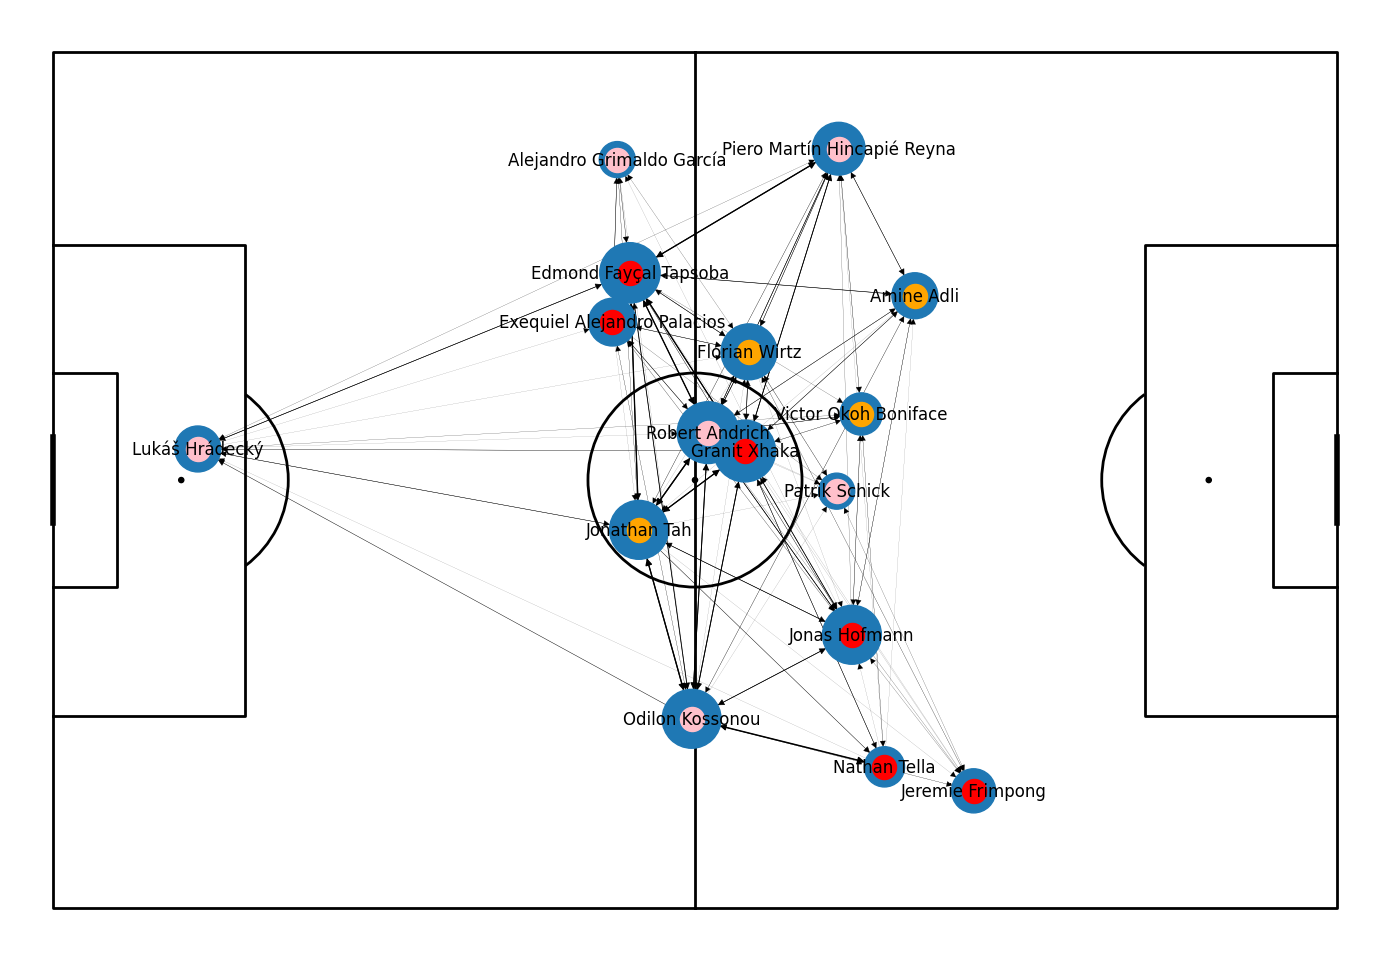

In [18]:
draw_spring(G = G_team_match_dist, pos = pos_team_match, com = G_team_match_dist_partition)

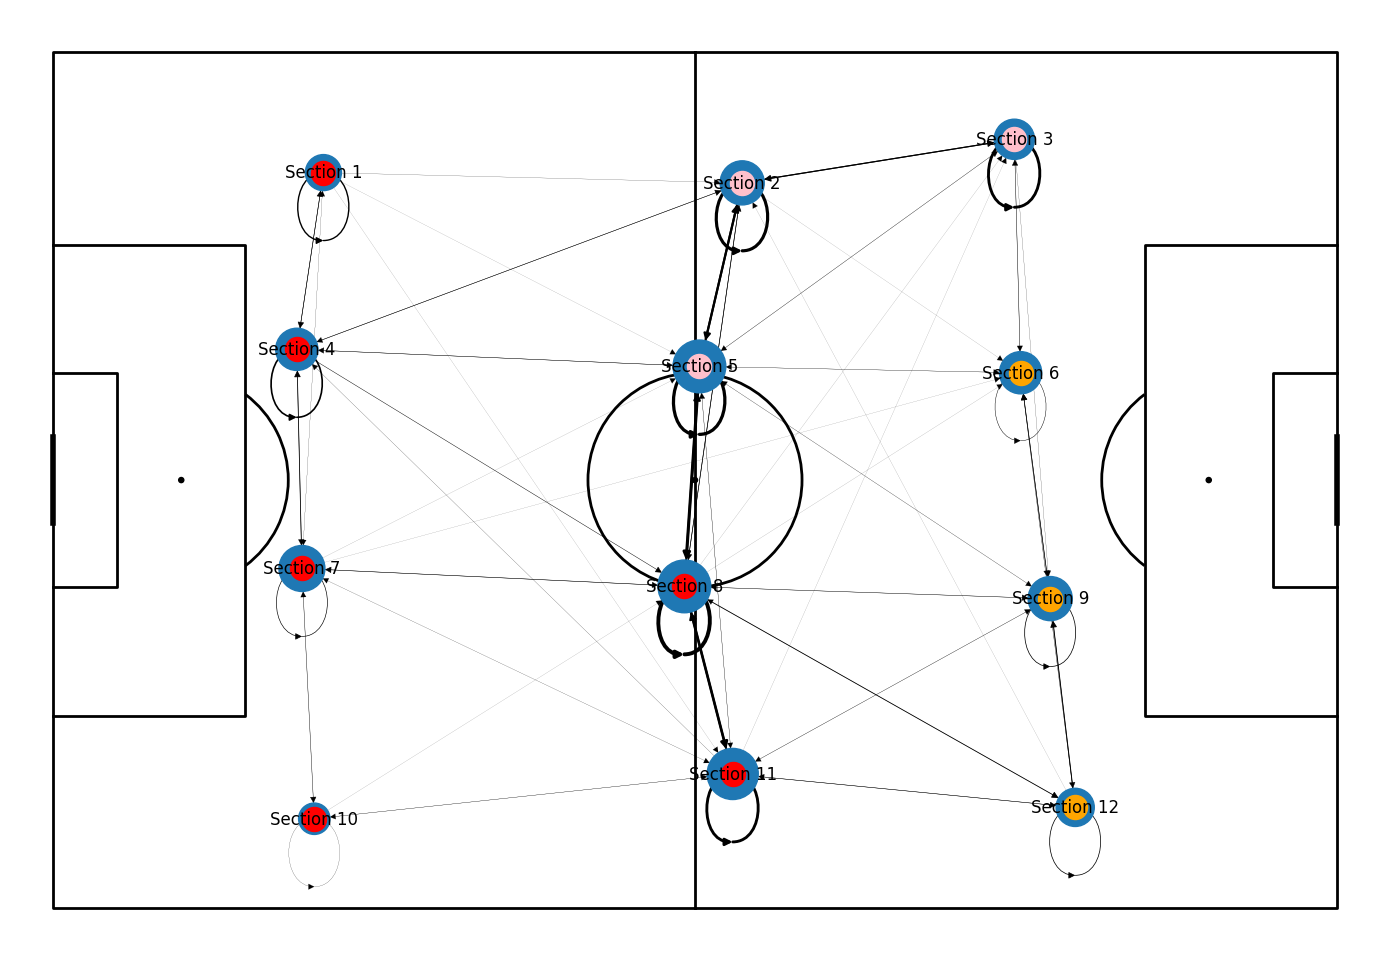

In [19]:
draw_spring(G = G_team_match_sec, pos = sec_team_match, com = G_team_match_sec_partition)

The implementation of the DCSBM, on the two network proposed highlights that:

    - The sections representation is able to express a more clear block structure with a segmentation of the nodes between:
        - Lower Block
        - Forward Triangle Block (2-3-5) with one playmakers area included
        - Forwarding Block withing the sections 6-9-12 that corresponde to the pitch section highlighted in the heatmap before
    - The player representation instead is unable to identify a clear blocks segmentation with a low intepretability of the results

#### <a id='sec3-3'></a> [3.3.](#sec3-3) Dynamic movement analysis - Passing motifs

According to the paper by Snijders, T. (2012). “Transitivity and triads.” University of Oxford, there are 16 Triad Types possible. This plot shows the 16 Triad Types that can be identified within directed networks. Triadic relationships are especially useful when analysing Social Networks. The first three digits refer to the number of mutual, asymmetric and null dyads (bidirectional, unidirection and nonedges) and the letter gives the Orientation as Up (U), Down (D) , Cyclical (C) or Transitive (T).
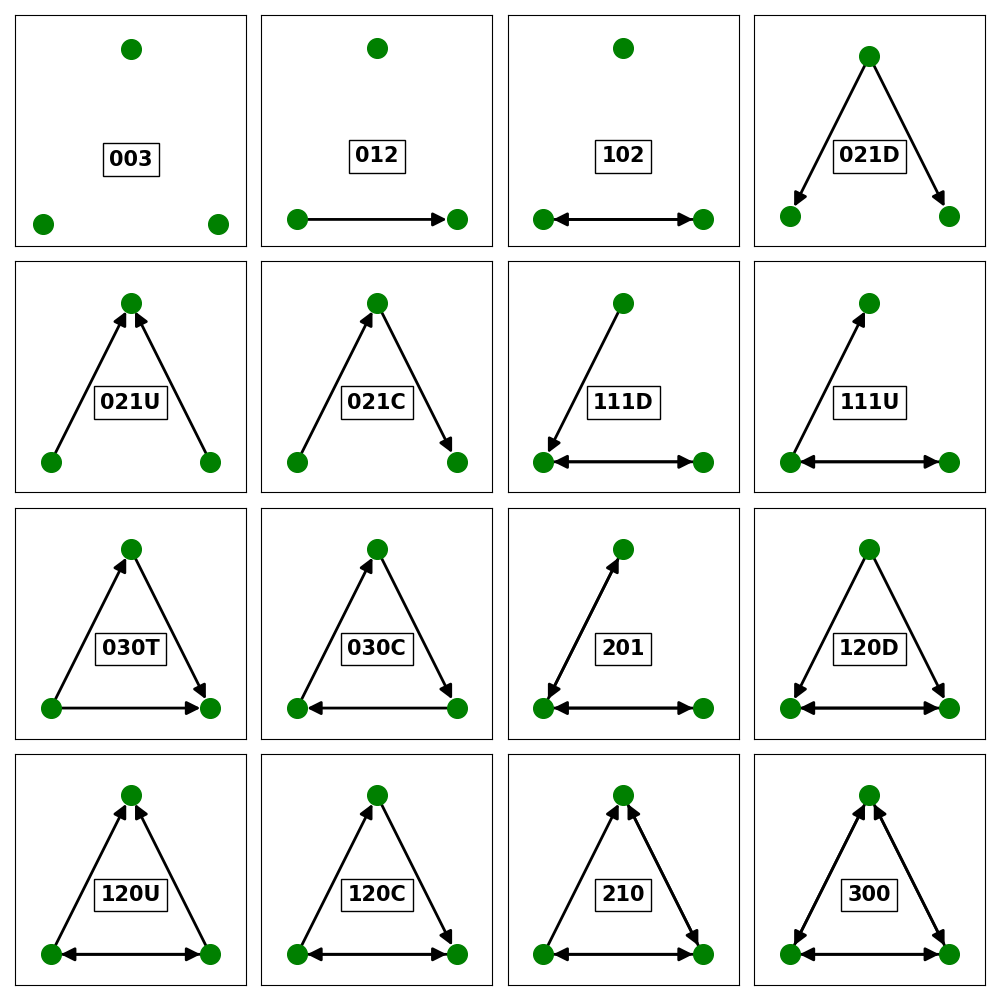

In [20]:
#entropy retrive
entropy_G_match_team_dist = metrics_G_match_team_dist['entropy_motif']

entropy_G_match_team_sec = metrics_G_match_team_sec['entropy_motif']

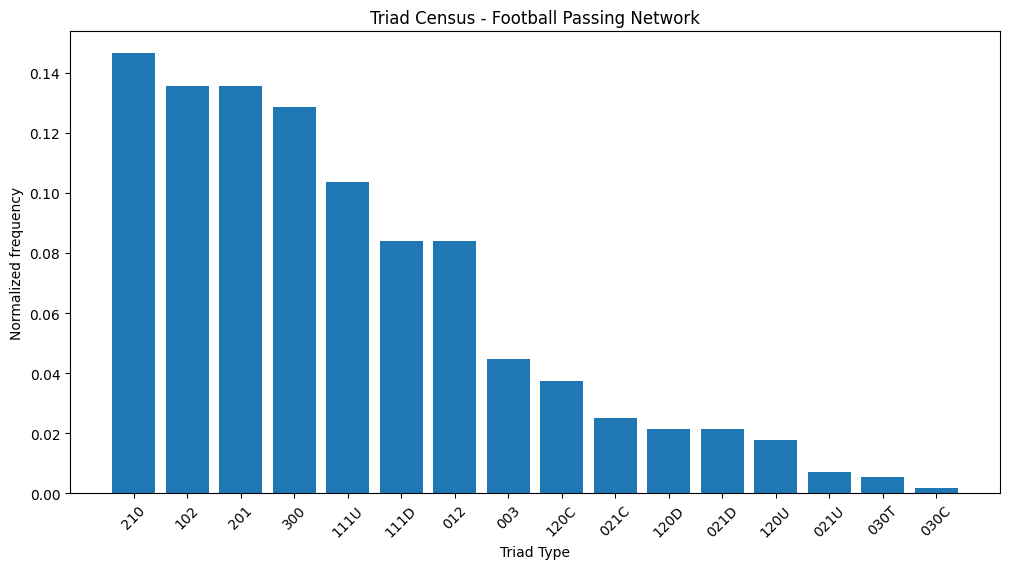

In [21]:
#triads computation and plot for the player based graph
triads_G_match_team_dist = compute_triad_census(G_team_match_dist)

plt.figure(figsize=(12,6))

plt.bar(
    triads_G_match_team_dist.index,
    triads_G_match_team_dist
)

plt.title("Triad Census - Football Passing Network")
plt.xlabel("Triad Type")
plt.ylabel("Normalized frequency")

plt.xticks(rotation=45)

plt.show()

The triad analysis captures more information within the player based network. A further analysis could be developed with a temporal frame as suggested by Yamamoto et al. (2011) [10] and Palazzo et al. (2023) [11]

### <a id='ch4'></a> [4.](#ch4) Multi-Match Analysis

This chapter is dedicated to the analysis and visualization of a set of matches for one team (Bayern Leverkusen - 34 matches) for the season 2023/24 to expand the tactical analysis using technique related to graph to reconstruct patterns or meaningful results. The resulting graph-level embeddings can subsequently be used for visualisation, clustering, match similarity analysis, and predictive modelling.
For each technique, a visualization on 2 dimensions will be provided using t-SNE and a cluster analysis using K-Means 

        - In Section 4.1 will be focused on graph features 
        - In Section 4.2 will be presented Graph2Vec, an embedding model that rework the more known Doc2Vec
        - In Section 4.3 will be introducted a deep learning model GATE, Graph Autoencor Attention, to reconstruct the graph and extract the latent space

### <a id='sec4-1'></a> [4.1.](#sec4-1) Features Representation

The graph features are directly referring to the chapter 3 and it has been used to create the dataframe for the visualisation/clustering

In [23]:
# set the parameters

competition_id = 9 #: Bundensliga
season_id=281 # : 2023/24 season

# collection of all the matches of that competition

matches = sb.matches(competition_id=competition_id,season_id=season_id)

In [24]:
# built a list of features for the graph from the match on matches filtering by one team for the player node based graph
G_matches_dist = build_features_graph(matches=matches,G_gen = G_dist_gen)
G_team_matches_dist = G_matches_dist[G_matches_dist["team_id"] == team_id].copy()

#pre work on the data before t-SNE and kMean
X_scaled, feature_cols = embedded_graphs_prep(G_team_matches_dist)

labels_graphs, kmeans_model = clustering_graph(X_scaled, K=3)

tsne_comp = tsne_features(X_scaled)

G_team_matches_dist["kMean_cluster"] = labels_graphs
G_team_matches_dist["tsne_1"] = tsne_comp[:, 0]
G_team_matches_dist["tsne_2"] = tsne_comp[:, 1]

  File "c:\Users\8andr\OneDrive\Desktop\Imperial_College_University\VS_Code\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\8andr\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\8andr\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_grou

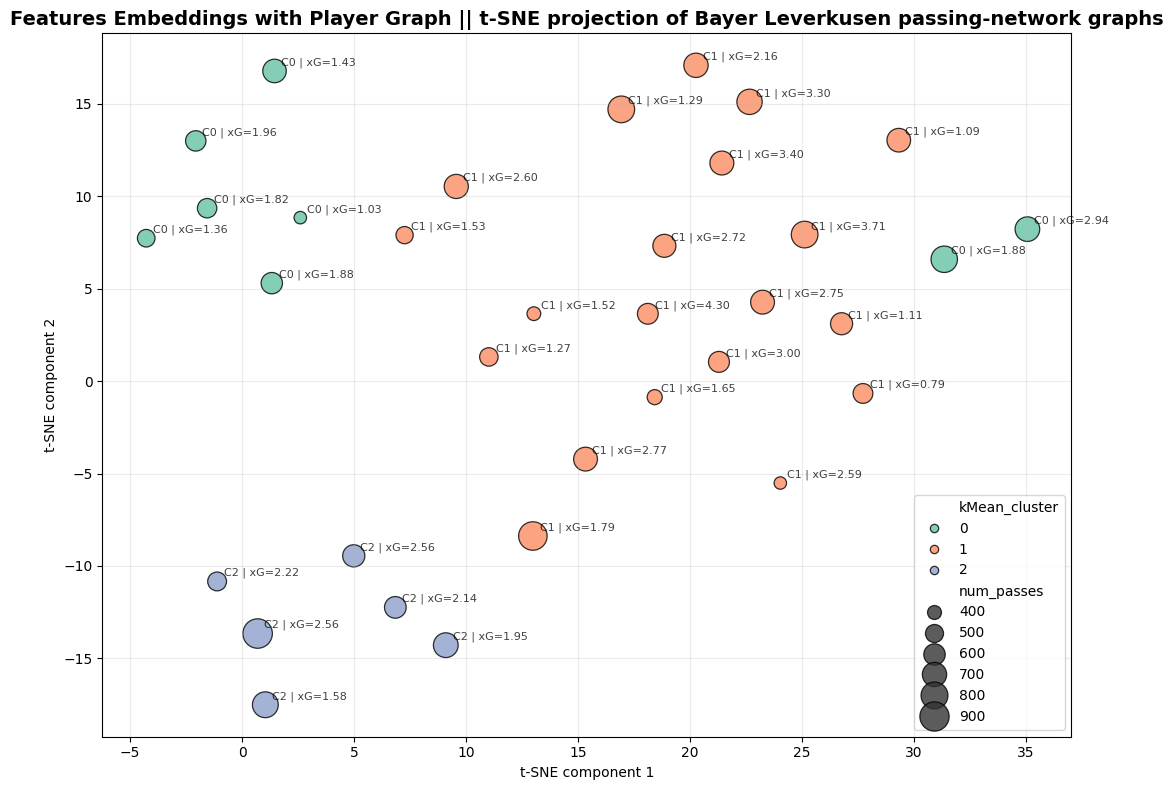

In [25]:
plot_tsne_kMean_graph_embedded(G_embedded=G_team_matches_dist,
                               label="Features Embeddings with Player Graph || t-SNE projection of Bayer Leverkusen passing-network graphs")

In [26]:
# built a list of features for the graph from the match on matches filtering by one team for the sectors node based graph
G_matches_sec = build_features_graph(matches=matches,G_gen = G_section_gen)
G_team_matches_sec = G_matches_sec[G_matches_sec["team_id"] == 904].copy()

X_scaled, feature_cols = embedded_graphs_prep(G_team_matches_sec)

labels_graphs, kmeans_model = clustering_graph(X_scaled, K=3)

tsne_comp = tsne_features(X_scaled)

G_team_matches_sec["kMean_cluster"] = labels_graphs
G_team_matches_sec["tsne_1"] = tsne_comp[:, 0]
G_team_matches_sec["tsne_2"] = tsne_comp[:, 1]

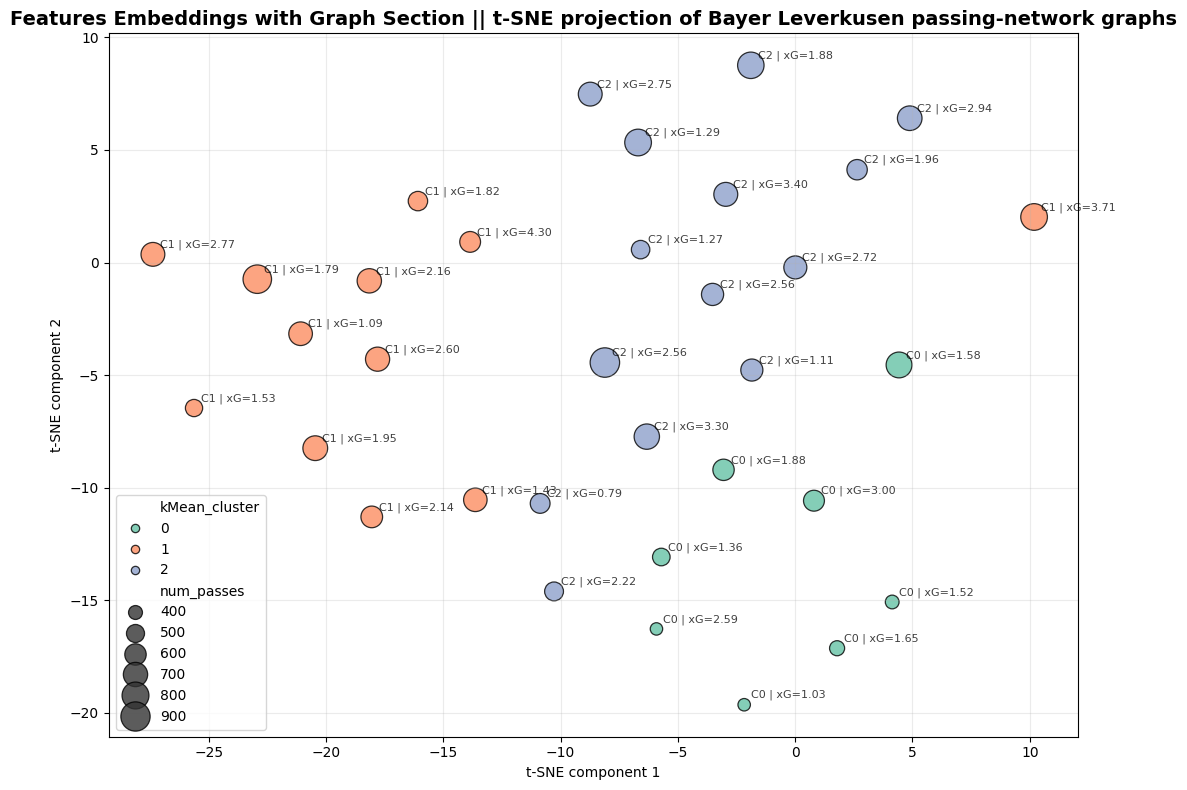

In [27]:
plot_tsne_kMean_graph_embedded(G_embedded=G_team_matches_sec,
                               label="Features Embeddings with Graph Section || t-SNE projection of Bayer Leverkusen passing-network graphs")

### <a id='sec4-2'></a> [4.2.](#sec4-2) Graph2Vec

In this section, we present a graph embedding approach based on **Graph2Vec**, introduced by Narayanan et al. (2017). The objective of Graph2Vec is to learn a fixed-dimensional vector representation for an entire graph, enabling graph-level comparison, clustering, and machine learning analysis. [8]

The key idea behind Graph2Vec is analogous to techniques used in natural language processing. In the same way that a document is represented by the words it contains, a graph is represented by the collection of local substructures surrounding its nodes. These local substructures are referred to as **rooted subgraphs** and play a role similar to words in a document.

Graph2Vec is used to obtain **unsupervised graph-level embeddings** for each passing network.

Formally, given a collection of graphs $\mathcal{G} = \{G_1, G_2, \ldots, G_n\}$, Graph2Vec learns an embedding matrix

$$
\Phi \in \mathbb{R}^{|\mathcal{G}| \times \delta},
$$

where:

- $|\mathcal{G}|$ is the number of graphs,
- $\delta$ is the embedding dimension,
- each row of $\Phi$ represents a graph-level embedding.

Since the passing networks are initially unlabeled, the degree of each node is used as the initial node label. Following Narayanan A. et al on their paper related to Graph2Vec

---

#### Graph2Vec Pipeline

The overall workflow is illustrated below:

```text
Football Match
      ↓
Passing Network
      ↓
Weisfeiler-Lehman Relabelling
      ↓
Rooted Subgraph Extraction
      ↓
TaggedDocument Creation
      ↓
Doc2Vec Training
      ↓
Graph Embedding Vector
```

---

#### Weisfeiler-Lehman Relabelling

To generate meaningful graph features, Graph2Vec employs the **Weisfeiler-Lehman (WL) relabelling algorithm**.

Starting from the initial node labels (node degrees), the algorithm iteratively updates each node label by combining:

1. The current label of the node.
2. The labels of its neighbouring nodes.

At each iteration, the neighbourhood information expands, allowing the representation to capture increasingly larger local structures within the passing network.

After several iterations, every node is associated with a sequence of rooted subgraph labels that describe its local connectivity pattern. In this example we have proposed a solution with 2 iterations.

---

#### Rooted Subgraphs as Words

Graph2Vec treats the rooted subgraphs extracted through WL relabelling as a vocabulary.

The analogy with natural language processing is:

| Natural Language Processing | Graph2Vec |
|-----------------------------|-----------|
| Word | Rooted subgraph |
| Document | Graph |
| Corpus | Collection of graphs |
| Word embedding | Subgraph representation |
| Document embedding | Graph embedding |

Consequently, each football match graph is transformed into a "document" composed of rooted subgraph labels.

---

#### Learning Graph Representations

Once the rooted subgraphs have been extracted, each graph is converted into a `TaggedDocument` and used to train a **Doc2Vec** model.

The training procedure follows the Skip-Gram paradigm, where the model learns graph embeddings that maximise the probability of observing rooted subgraphs belonging to the same graph.

Graphs with similar local structures therefore obtain similar vector representations in the embedding space.

In [ ]:
# creation of the documents for each graph
documents_graph_dist = build_graph2vec_documents(matches=matches,G_gen = G_dist_gen)

random_seed = 10

#Doc2Vec embedding algorithm
model_graph2vec_dist = Doc2Vec(documents_graph_dist,vector_size=128,window=0,min_count=1,dm=0,
                epochs=100,seed=random_seed,workers=1
                )

match_ids = G_matches_dist["match_id"].astype(str).unique()

#extraction of the embedded graph - str(match_id) is the tagged document
embeddings = np.array([
    model_graph2vec_dist.dv[str(match_id)] # should follow the same tag logics dv[str(match_id*10000 + team_id)]
    for match_id in match_ids
])

embedding_df = pd.DataFrame(
    embeddings,
    columns=[f"g2v_{i}" for i in range(embeddings.shape[1])]
)

embedding_df["match_id"] = G_matches_dist["match_id"].unique()

graph2vec_dist = G_matches_dist[["match_id", "team_id", "xg_team_match"]].merge(
    embedding_df,
    on="match_id"
)

graph2vec_dist=graph2vec_dist[graph2vec_dist['team_id']==team_id]

graph2vec_dist.head(5)


,match_id,team_id,xg_team_match,g2v_0,g2v_1,g2v_2,g2v_3,g2v_4,g2v_5,g2v_6,...,g2v_118,g2v_119,g2v_120,g2v_121,g2v_122,g2v_123,g2v_124,g2v_125,g2v_126,g2v_127
1,3895292,904,2.563543,0.084041,0.441023,0.419803,0.815344,0.784917,0.367173,-0.945207,...,0.719243,0.135425,1.002754,0.001898,-0.966761,-0.260441,-0.106217,-0.050278,-0.978826,0.295723
2,3895320,904,1.652524,-0.403095,0.917575,0.158855,-0.055609,1.175586,0.618275,0.121664,...,-0.485224,1.003641,0.940439,0.549537,-0.859534,-0.819747,-0.280273,0.920293,-0.016672,0.071356
4,3895158,904,2.144727,0.441191,-0.546013,-0.725085,-0.341662,0.775590,-0.238229,-0.316573,...,-0.250740,0.649163,1.107797,0.657912,0.358795,0.449194,0.535931,0.085790,-0.266270,-0.170363
6,3895107,904,2.942169,1.037366,-0.399157,0.123013,-0.098466,0.155552,0.922516,-0.252983,...,-0.646518,-0.754246,-0.434731,-0.358296,-0.638702,0.423002,-0.854900,0.190376,-0.333423,-0.760243
9,3895340,904,4.301661,0.192183,0.304155,0.688629,-0.805869,1.105531,0.210065,-0.946863,...,0.223368,0.246844,0.116875,0.613252,-0.449495,-0.929719,0.682163,-0.769682,-0.187781,0.405293


In [29]:
X_scaled, feature_cols = embedded_graphs_prep(graph2vec_dist)

labels_graphs, kmeans_model = clustering_graph(X_scaled, K=3)

tsne_comp = tsne_features(X_scaled)

graph2vec_dist["num_passes"] = G_team_matches_dist['num_passes']
graph2vec_dist["kMean_cluster"] = labels_graphs
graph2vec_dist["tsne_1"] = tsne_comp[:, 0]
graph2vec_dist["tsne_2"] = tsne_comp[:, 1]

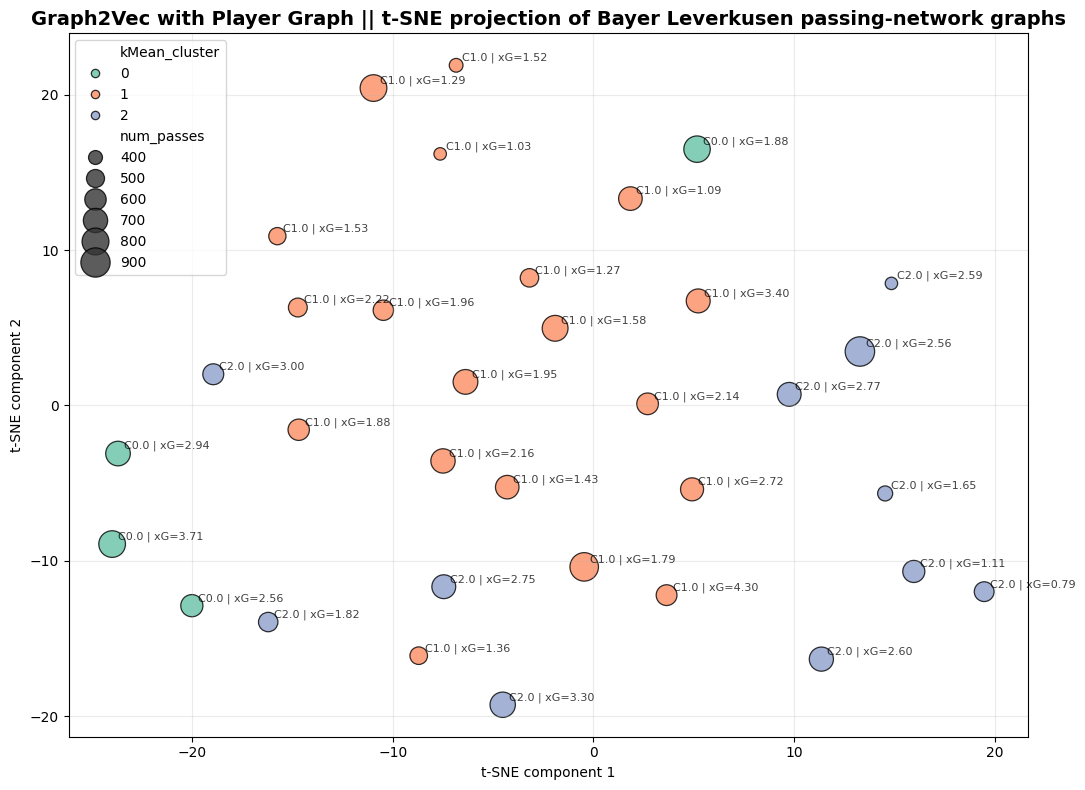

In [30]:
plot_tsne_kMean_graph_embedded(G_embedded=graph2vec_dist,
                               label="Graph2Vec with Player Graph || t-SNE projection of Bayer Leverkusen passing-network graphs")

### <a id='sec4-3'></a> [4.3.](#sec4-3) Graph Attention Autoencoder (GATE)

In this section, we introduce a deep learning framework based on the work of Lee et al. (2025) and Salehi & Davulcu (2019). The objective of the model is to learn low-dimensional graph representations of football passing networks while preserving their structural information. [7] [9]

The model is based on a **Graph Attention Autoencoder (GATE)** architecture, which combines Graph Attention Networks (GATs) with an autoencoder framework. The encoder learns node embeddings from the passing network, while the decoder attempts to reconstruct the original network structure from these embeddings.

---

#### Model Architecture

The overall workflow is illustrated below:

```text
Football Match
      ↓
Passing Network
      ↓
Node Feature Matrix X
Adjacency Matrix A
      ↓
Graph Attention Encoder (GAT)
      ↓
Node Embeddings Z
      ↓
Mean Pooling
      ↓
Match Embedding
      ↓
Inner-Product Decoder
      ↓
Reconstructed Adjacency Matrix Â
```

---

#### Model Assumptions

The following assumptions are adopted throughout the analysis:

1. All graphs are padded to the same number of nodes.
2. The model reconstructs binary passing connections rather than exact pass frequencies.
3. Node attributes are represented by graph-derived features.
4. Mean pooling is used to obtain a graph-level representation.
5. The original passing network is directed, although the decoder reconstructs a symmetric adjacency matrix.

---

#### Graph Attention Encoder

The encoder is based on the Graph Attention Network (GAT) architecture proposed by Velickovic et al. (2018).

The objective of the encoder is to learn a vector representation for each player by aggregating information from neighbouring players while assigning different importance weights to each neighbour.

For a node $i$, the updated embedding is computed as

$$
h_i'
=
\text{ELU}
\left(
\sum_{j \in \mathcal{N}(i)}
\alpha_{ij} W h_j
\right)
$$

where:

- $h_i$ is the original feature vector of player $i$
- $W$ is a trainable weight matrix
- $\alpha_{ij}$ is the attention coefficient between players $i$ and $j$
- $h_i'$ is the updated node representation
- $\mathcal{N}(i)$ denotes the neighbourhood of node $i$

---

#### Attention Mechanism

A key characteristic of GATs is that neighbouring nodes contribute differently to the updated representation.

The attention coefficients are computed using a softmax normalisation:

$$
\alpha_{ij}
=
\frac{\exp(e_{ij})}
{\sum_{k \in \mathcal{N}(i)}
\exp(e_{ik})}
$$

where $e_{ij}$ represents the raw attention score between nodes $i$ and $j$.
It is composed by 2 steps mechanism.

Step 1: Compute Raw Attention Scores

The raw attention score is calculated as

$$
e_{ij}
=
\text{LeakyReLU}
\left(
a^T
[
Wh_i \, || \, Wh_j
]
\right)
$$

where:

- $a$ is a trainable attention vector
- $W$ is the shared weight matrix
- $[Wh_i || Wh_j]$ denotes vector concatenation
- LeakyReLU is the activation function

This operation measures the importance of player $j$ when updating player $i$.

Step 2: Mask Non-Existing Edges

Attention is only computed for existing passing connections.

Therefore,

$$
e_{ij}
=
\begin{cases}
e_{ij}, & \text{if } A_{ij}>0 \\
-\infty, & \text{otherwise}
\end{cases}
$$

This ensures that attention is assigned only to connected players.

---

#### Node Embeddings

The graph encoder is composed of two stacked GAT layers.

The first layer computes:

$$
H_1
=
\text{GATEncoder}(X,A)
$$

The second layer refines these representations:

$$
H_2
=
\text{GATEncoder}(H_1,A)
$$

The final node embeddings are therefore

$$
Z = H_2
$$

where each row $z_i$ represents the latent embedding of player $i$.

These embeddings capture both:

- Node-specific characteristics
- Local passing structure

---

#### Mean Pooling

To obtain a graph-level representation of the match, node embeddings are aggregated using mean pooling.

The graph embedding is defined as

$$
Z_G
=
\frac{1}{|V|}
\sum_{i=1}^{|V|}
z_i
$$

where:

- $Z_G$ is the match-level embedding
- $|V|$ is the number of nodes
- $z_i$ is the embedding of node $i$

Mean pooling generates a fixed-dimensional representation regardless of the graph size.

---

#### Inner-Product Decoder

The decoder reconstructs the adjacency matrix from the learned node embeddings.

A simple inner-product decoder combined with a sigmoid activation function is used:

$$
\hat{A}
=
\text{Sigmoid}
\left(
ZZ^T
\right)
$$

where:

- $Z$ is the matrix of node embeddings
- $\hat{A}$ is the reconstructed adjacency matrix

The reconstructed value $\hat{A}_{ij}$ can be interpreted as the probability that a passing connection exists between players $i$ and $j$.

---

#### Loss Function

The model is trained using Binary Cross-Entropy (BCE) loss. The objective is to reconstruct whether a passing connection exists rather than predicting the exact number of passes. The loss function is defined as


$$
\mathcal{L}
=
-\frac{1}{N^2}
\sum_{i,j}
\left[
A_{ij}
\log(\hat{A}_{ij})
+
(1-A_{ij})
\log(1-\hat{A}_{ij})
\right]
$$

where:

- $A_{ij}$ is the observed adjacency matrix
- $\hat{A}_{ij}$ is the reconstructed adjacency matrix
- $N$ is the number of nodes

Minimising this loss encourages the model to produce embeddings that preserve the structural characteristics of the original passing network.

In [ ]:
X_all, A_all, max_nodes_dist = build_graph_dataset(
    matches=matches, G_gen = G_dist_gen,
)

X_scaled, feature_scaler = scale_node_features(X_all)

X_tensor = tf.convert_to_tensor(X_scaled, dtype=tf.float32)
A_tensor = tf.convert_to_tensor(A_all, dtype=tf.float32)

input_tensor = [X_tensor,A_tensor]


gate_model = GraphAttentionAutoencoder(hidden_dim=64, embedding_dim=128)

optimizer_gate_model = tf.keras.optimizers.Adam(learning_rate=0.001)

losses_gae_model = train_gate(
    model= gate_model,
    optimizer= optimizer_gate_model,
    input_tensor= input_tensor,
    epochs=300
)


Epoch 000 | Loss: 2.8549
Epoch 050 | Loss: 0.6987
Epoch 100 | Loss: 0.6955
Epoch 150 | Loss: 0.6945
Epoch 200 | Loss: 0.6941
Epoch 250 | Loss: 0.6938


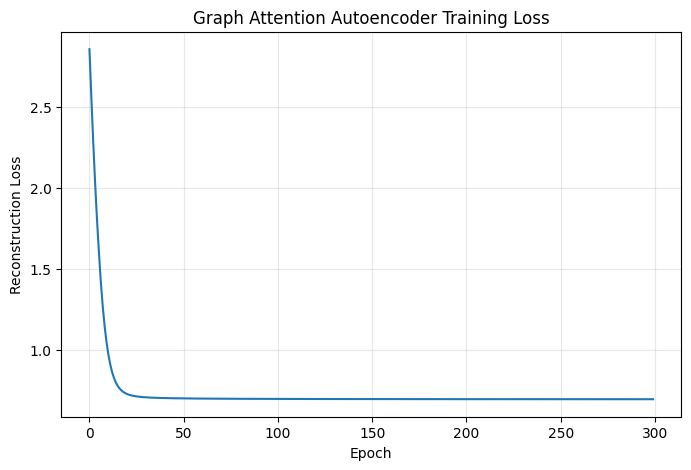

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(losses_gae_model)

plt.title("Graph Attention Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.grid(alpha=0.3)

plt.show()

In [ ]:
graph_embeddings = gate_model.embed_graphs(
    X_tensor,
    A_tensor
).numpy()

graph_embeddings = pd.DataFrame(
    graph_embeddings,
    columns=[
        f"gate_{i}"
        for i in range(graph_embeddings.shape[1])
    ]
)

graph_embeddings[["match_id", "team_id"]] = G_matches_dist[["match_id", "team_id"]]

graph_embeddings=graph_embeddings[graph_embeddings['team_id']==team_id]

gate_graph_embeddings_disc = G_team_matches_dist[["match_id", "xg_team_match","num_passes"]].merge(
    graph_embeddings,
    on="match_id"
)
gate_graph_embeddings_disc.head(2)

,match_id,xg_team_match,num_passes,gate_0,gate_1,gate_2,gate_3,gate_4,gate_5,gate_6,...,gate_119,gate_120,gate_121,gate_122,gate_123,gate_124,gate_125,gate_126,gate_127,team_id
0,3895292,2.563543,625,0.017724,-0.002438,-0.022995,0.001807,0.013039,0.015275,0.015971,...,0.010780,0.026917,-0.016001,0.007753,0.008112,0.004514,0.010555,-0.037742,0.008802,904
1,3895320,1.652524,425,0.001054,0.000010,-0.004106,0.000447,0.000181,0.000674,0.000296,...,-0.000462,0.001010,0.000075,-0.001551,0.001337,0.000009,0.000190,-0.003059,0.000238,904


In [34]:
X_scaled, feature_cols = embedded_graphs_prep(gate_graph_embeddings_disc)

labels_graphs, kmeans_model = clustering_graph(X_scaled, K=3)

tsne_comp = tsne_features(X_scaled)

gate_graph_embeddings_disc["kMean_cluster"] = labels_graphs
gate_graph_embeddings_disc["tsne_1"] = tsne_comp[:, 0]
gate_graph_embeddings_disc["tsne_2"] = tsne_comp[:, 1]

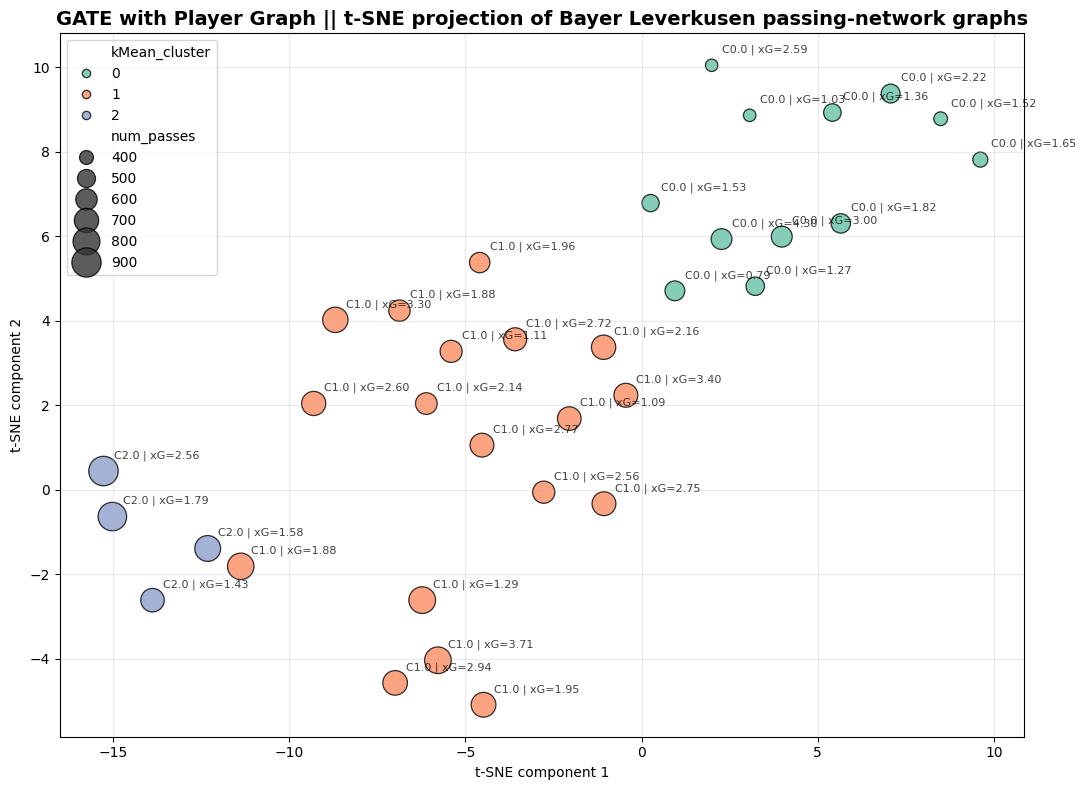

In [35]:
plot_tsne_kMean_graph_embedded(G_embedded=gate_graph_embeddings_disc,
                               label="GATE with Player Graph || t-SNE projection of Bayer Leverkusen passing-network graphs")

In [ ]:
X_all, A_all, max_nodes_sec = build_graph_dataset(
    matches=matches, G_gen = G_section_gen,
)

X_scaled, feature_scaler = scale_node_features(X_all)

X_tensor = tf.convert_to_tensor(X_scaled, dtype=tf.float32)
A_tensor = tf.convert_to_tensor(A_all, dtype=tf.float32)

input_tensor = [X_tensor,A_tensor]


gate_model = GraphAttentionAutoencoder(hidden_dim=64, embedding_dim=128)

optimizer_gate_model = tf.keras.optimizers.Adam(learning_rate=0.001)

losses_gae_model = train_gate(
    model= gate_model,
    optimizer= optimizer_gate_model,
    input_tensor= input_tensor,
    epochs=300
)

Epoch 000 | Loss: 1.9766
Epoch 050 | Loss: 0.6894
Epoch 100 | Loss: 0.6865
Epoch 150 | Loss: 0.6838
Epoch 200 | Loss: 0.6803
Epoch 250 | Loss: 0.6765


In [ ]:
graph_embeddings = gate_model.embed_graphs(
    X_tensor,
    A_tensor
).numpy()

graph_embeddings = pd.DataFrame(
    graph_embeddings,
    columns=[
        f"gate_{i}"
        for i in range(graph_embeddings.shape[1])
    ]
)

graph_embeddings[["match_id", "team_id"]] = G_matches_sec[["match_id", "team_id"]]

graph_embeddings=graph_embeddings[graph_embeddings['team_id']==team_id]

gate_graph_embeddings_sec = G_team_matches_sec[["match_id", "xg_team_match","num_passes"]].merge(
    graph_embeddings,
    on="match_id"
)

In [38]:
X_scaled, feature_cols = embedded_graphs_prep(gate_graph_embeddings_sec)

labels_graphs, kmeans_model = clustering_graph(X_scaled, K=3)

tsne_comp = tsne_features(X_scaled)

gate_graph_embeddings_sec["kMean_cluster"] = labels_graphs
gate_graph_embeddings_sec["tsne_1"] = tsne_comp[:, 0]
gate_graph_embeddings_sec["tsne_2"] = tsne_comp[:, 1]

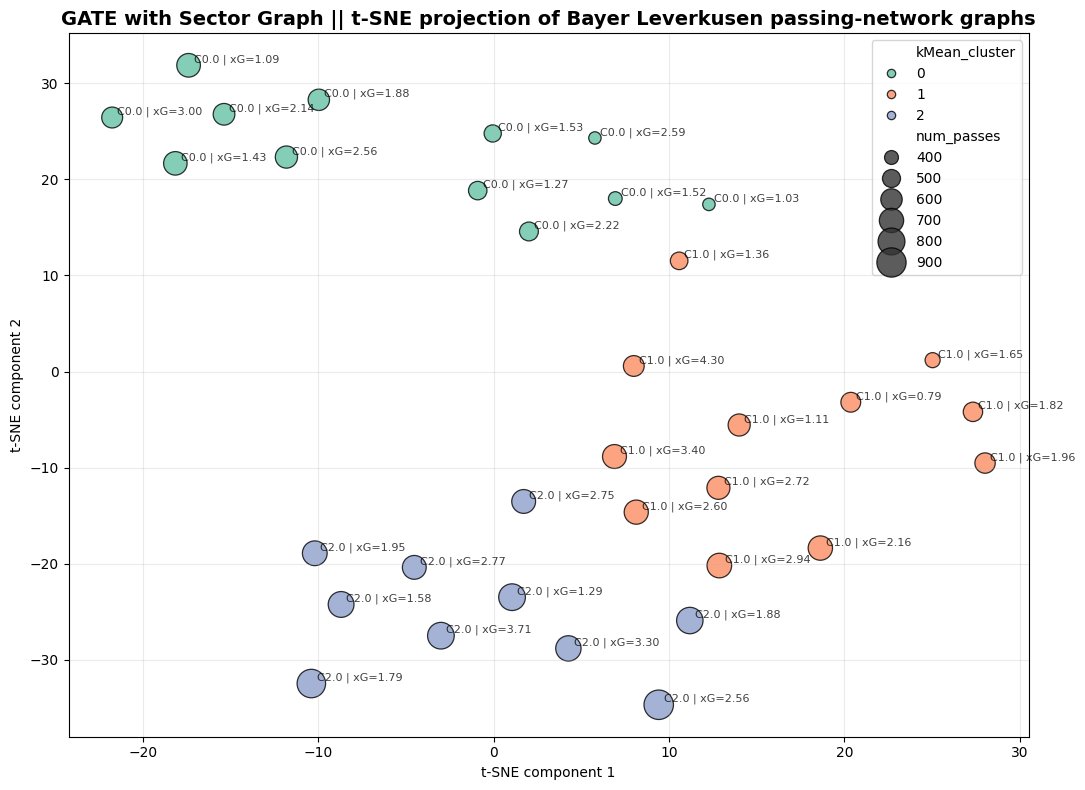

In [39]:
plot_tsne_kMean_graph_embedded(G_embedded=gate_graph_embeddings_sec,
                               label="GATE with Sector Graph || t-SNE projection of Bayer Leverkusen passing-network graphs")

### Graph Attention Autoencoder (GATE) - Alternative Model with Graph Features

While the Graph Attention Autoencoder introduced in the previous section effectively captures local passing interactions between players, it does not explicitly incorporate global structural characteristics of the passing network.

Important tactical information such as network density, modularity, clustering coefficient, and centralization is therefore only indirectly available to the model through the adjacency structure.

To address this limitation, we propose an enhanced architecture that combines:

1. **Node-level information** (as before)
   - Node-specific features
   - Local passing relationships

2. **Graph-level information** (new features)
   - Global network statistics
   - Tactical characteristics of the entire match

The objective is to learn graph embeddings that simultaneously capture both local player interactions and global team organisation.

---

#### Enhanced Architecture

The proposed architecture extends the original Graph Attention Autoencoder by introducing two additional layers:

- **GATEncoderGraph**
- **GATDecoderGraph**

The complete workflow is illustrated below:

```text
Football Match
      ↓
Passing Network
      ↓
Node Features X
Adjacency Matrix A
Graph Features X_G
      ↓
GAT Encoder
      ↓
GATEncoderGraph
      ↓
GATDecoderGraph
      ↓
Inner-Product Decoder
      ↓
Reconstructed Adjacency Matrix Â
```

---

#### GATEncoderGraph

The purpose of the GATEncoderGraph layer is to enrich the learned graph representation with global network information.

After the standard GAT encoder has generated node embeddings, a graph-level embedding is obtained through mean pooling.

The pooled graph representation is defined as

$$
z_G
=
\frac{1}{N}
\sum_{i=1}^{N}
z_i
$$

where:

- $z_i$ is the embedding of player $i$
- $N$ is the number of nodes (players)
- $z_G$ is the pooled graph embedding

---

#### Incorporating Graph Features

Let $x_G$ denote a vector containing graph-level metrics extracted from the passing network. The features used for this model are the same used in the chapter 4.1 when a feature embedding solution has been discussed and presented.

The pooled graph embedding and the graph features are concatenated:

$$
h_G
=
[z_G \, || \, x_G]
$$

where $||$ denotes vector concatenation.

This operation combines:

- Information learned automatically by the GAT encoder
- Graph-theoretical features

---

#### Graph Embedding Projection

The concatenated representation is then passed through a connected layer with linear activation function:

$$
e_G
=
W_G h_G + b_G
$$

where:

- $W_G$ is a trainable weight matrix
- $b_G$ is a trainable bias vector
- $e_G$ is the final graph embedding

This embedding represents the complete tactical structure of the football match.

---

#### GATDecoderGraph & Reshaping Operation

The purpose of the GATDecoderGraph layer is to increase the flexibility of the decoder and allow additional transformations of the graph embedding before reconstructing the adjacency matrix.

Rather than directly feeding the graph embedding into the inner-product decoder, an additional layer is introduced with a ReLU activation function.

The transformed embedding is computed as

$$
d_G
=
\text{ReLU}
\left(
W_D e_G + b_D
\right)
$$

where:

- $W_D$ is a trainable weight matrix
- $b_D$ is a trainable bias vector

The transformed embedding is subsequently reshaped into a matrix:

$$
D_G
=
\text{reshape}(d_G, N, N)
$$

where:

- $N$ is the number of nodes
- $D_G$ is an intermediate representation used by the decoder

These layers allow the model to learn non-linear combinations of the graph-level features and to prepare the graph emebedded representation for the final adjacency reconstruction step.

---

#### Inner-Product Decoder

The reshaped representation is then passed to the standard inner-product decoder to reconstruct the adjacency matrix.

The reconstructed adjacency matrix is

$$
\hat{A}
=
\text{Sigmoid}
\left(
D_G D_G^T
\right)
$$

where:

- $\hat{A}$ is the reconstructed adjacency matrix

The output can be interpreted as the probability that a passing connection exists between two players.

---

#### Motivation

The original Graph Attention Autoencoder learns representations solely from node features and graph connectivity.

The enhanced architecture additionally incorporates graph-theoretical metrics describing the global structure of the passing network.

This provides a more flexible model that can learn information also on a graph level before the embedding stage.

By combining learned node representations with handcrafted graph metrics, the model captures both micro-level player interactions and macro-level team behaviour, providing a richer representation of football tactics.

In [40]:
X_all, A_all, max_nodes_dist = build_graph_dataset(
    matches=matches, G_gen = G_dist_gen)

X_scaled, feature_scaler = scale_node_features(X_all)

feature_scaled, feature_cols = embedded_graphs_prep(G_matches_dist)

X_tensor = tf.convert_to_tensor(X_scaled, dtype=tf.float32)
A_tensor = tf.convert_to_tensor(A_all, dtype=tf.float32)
feature_tensor = tf.convert_to_tensor(feature_scaled, dtype=tf.float32)

input_tensor = [X_tensor,A_tensor,feature_tensor]


gate_model_adjust = GraphAttentionAutoencoderWithGraphFeatures(n_nodes= max_nodes_dist,hidden_dim=64,node_embedding_dim=128,graph_embedding_dim=128)

optimizer_gate_model_adjust = tf.keras.optimizers.Adam(learning_rate=0.001)

losses_gate_model_adjust = train_gate(
    model= gate_model_adjust,
    optimizer= optimizer_gate_model_adjust,
    input_tensor= input_tensor,
    epochs=300
)

Epoch 000 | Loss: 0.8010
Epoch 050 | Loss: 0.6546
Epoch 100 | Loss: 0.6352
Epoch 150 | Loss: 0.6252
Epoch 200 | Loss: 0.6195
Epoch 250 | Loss: 0.6161


In [41]:
graph_embeddings = gate_model_adjust.embed_graphs([
    X_tensor,
    A_tensor,
    feature_tensor]
).numpy()

graph_embeddings = pd.DataFrame(
    graph_embeddings,
    columns=[
        f"gate_{i}"
        for i in range(graph_embeddings.shape[1])
    ]
)

graph_embeddings[["match_id", "team_id"]] = G_matches_dist[["match_id", "team_id"]]

graph_embeddings=graph_embeddings[graph_embeddings['team_id']==team_id]

gate_graph_embeddings_dist_adjust = G_team_matches_dist[["match_id", "xg_team_match","num_passes"]].merge(
    graph_embeddings,
    on="match_id"
)

In [42]:
X_scaled, feature_cols = embedded_graphs_prep(gate_graph_embeddings_dist_adjust)

labels_graphs, kmeans_model = clustering_graph(X_scaled, K=3)

tsne_comp = tsne_features(X_scaled)

gate_graph_embeddings_dist_adjust["kMean_cluster"] = labels_graphs
gate_graph_embeddings_dist_adjust["tsne_1"] = tsne_comp[:, 0]
gate_graph_embeddings_dist_adjust["tsne_2"] = tsne_comp[:, 1]

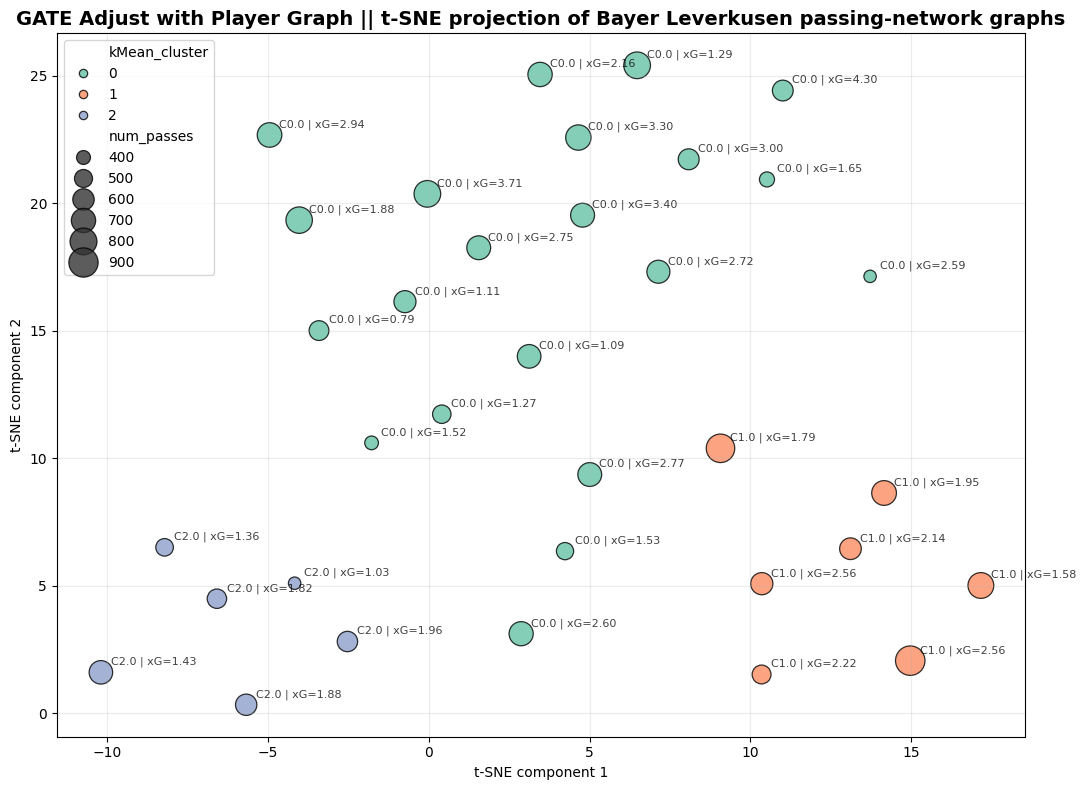

In [43]:
plot_tsne_kMean_graph_embedded(G_embedded=gate_graph_embeddings_dist_adjust,
                               label="GATE Adjust with Player Graph || t-SNE projection of Bayer Leverkusen passing-network graphs")

The overall capabilities of the methods to cluster efficiently the group has been shown by the representation in 2 dimension of t-SNE. On a more qualitative check, the GATE models (standard and enrich with the graph features), seem more capable to cluster group of matches compare to Graph2Vec, while the simplest model based only on match features, shows strong performance. 

The key highlights on the small panel of examples are:

        - Methods that leverage on the graph features tends to cluster better and have a visual segmentation more defined
        - Graph2Vec has a spare results graphically and does solely rely on graph connectivity not using any information about the overall graph
        - The methods tend to work better with the sector graph based model rather than the player based graph model

As last topic we proposed further analysis to be performed:

        - Analysing the clusters generated by the different methods and their components
        - Introducting a time analysis on the triads distribution and any possible links with offensive tactical perfomances
        - Add new spacial features related to the graph on nodes/edges (position of the player, distance of the passes) that can enrich the model with positional based information
        - Redefine the weighted Adjacency matrix with an alternative frame for the edge weights: more importance to passes that happened in offensive areas of the pitch rather than in defensive zones
        - Comparison between seasons and tournaments

### <a id='ch5'></a> [5.](#ch5) References

#### Graph Representation Learning & Graph Embeddings

Hamilton, W.L. (2020) *Graph Representation Learning*. San Rafael, CA: Morgan & Claypool Publishers.

Narayanan, A., Chandramohan, M., Venkatesan, R., Chen, L., Liu, Y. and Jaiswal, S. (2017) *graph2vec: Learning Distributed Representations of Graphs*. arXiv preprint arXiv:1707.05005. Available at: https://arxiv.org/abs/1707.05005

Kriege, N.M., Johansson, F.D. and Morris, C. (2020) ‘A survey on graph kernels’, *Applied Network Science*, 5(1), p. 6. https://doi.org/10.1007/s41109-019-0195-3

---

#### Graph Neural Networks & Auto-Encoders

Kipf, T.N. and Welling, M. (2017) ‘Semi-Supervised Classification with Graph Convolutional Networks’, *Proceedings of the 5th International Conference on Learning Representations (ICLR 2017)*. Available at: https://arxiv.org/abs/1609.02907

Salehi, A. and Davulcu, H. (2019) *Graph Attention Auto-Encoders*. arXiv preprint arXiv:1905.10715. Available at: https://arxiv.org/abs/1905.10715

---

#### Stochastic Block Models

Holland, P.W., Laskey, K.B. and Leinhardt, S. (1983) ‘Stochastic blockmodels: First steps’, *Social Networks*, 5(2), pp. 109–137.

Karrer, B. and Newman, M.E.J. (2011) ‘Stochastic blockmodels and community structure in networks’, *Physical Review E*, 83(1), 016107. https://doi.org/10.1103/PhysRevE.83.016107

Latouche, P., Birmelé, E. and Ambroise, C. (2012) ‘Variational Bayesian inference and complexity control for stochastic block models’, *Statistical Modelling*, 12(1), pp. 93–115. https://doi.org/10.1177/1471082X1101200105

---

#### Football Passing Networks

Lee, J., Park, E. and del Pobil, A.P. (2025) ‘We know who wins: graph-oriented approaches of passing networks for predictive football match outcomes’, *Journal of Big Data*, 12, Article 147. https://doi.org/10.1186/s40537-025-01203-9

Palazzo, L., Ievoli, R. and Ragozini, G. (2023) ‘Testing styles of play using triad census distribution: an application to men’s football’, Journal of Quantitative Analysis in Sports, 19(4), pp. 261–276. https://doi.org/10.1515/jqas-2022-0010

Yamamoto, Y. and Yokoyama, K. (2011) ‘Common and unique network dynamics in football games’, PLOS ONE, 6(12), e29638. https://doi.org/10.1371/journal.pone.0029638

---

#### Alphabetical Reference List

1. Hamilton, W.L. (2020) *Graph Representation Learning*. San Rafael, CA: Morgan & Claypool Publishers.

2. Holland, P.W., Laskey, K.B. and Leinhardt, S. (1983) ‘Stochastic blockmodels: First steps’, *Social Networks*, 5(2), pp. 109–137.

3. Karrer, B. and Newman, M.E.J. (2011) ‘Stochastic blockmodels and community structure in networks’, *Physical Review E*, 83(1), 016107.

4. Kipf, T.N. and Welling, M. (2017) ‘Semi-Supervised Classification with Graph Convolutional Networks’, *Proceedings of the 5th International Conference on Learning Representations (ICLR 2017)*.

5. Kriege, N.M., Johansson, F.D. and Morris, C. (2020) ‘A survey on graph kernels’, *Applied Network Science*, 5(1), p. 6.

6. Latouche, P., Birmelé, E. and Ambroise, C. (2012) ‘Variational Bayesian inference and complexity control for stochastic block models’, *Statistical Modelling*, 12(1), pp. 93–115.

7. Lee, J., Park, E. and del Pobil, A.P. (2025) ‘We know who wins: graph-oriented approaches of passing networks for predictive football match outcomes’, *Journal of Big Data*, 12, Article 147.

8. Narayanan, A., Chandramohan, M., Venkatesan, R., Chen, L., Liu, Y. and Jaiswal, S. (2017) *graph2vec: Learning Distributed Representations of Graphs*. arXiv preprint arXiv:1707.05005.

9. Salehi, A. and Davulcu, H. (2019) *Graph Attention Auto-Encoders*. arXiv preprint arXiv:1905.10715.

10. Palazzo, L., Ievoli, R. and Ragozini, G. (2023) ‘Testing styles of play using triad census distribution: an application to men’s football’, Journal of Quantitative Analysis in Sports, 19(4), pp. 261–276. https://doi.org/10.1515/jqas-2022-0010

11. Yamamoto, Y. and Yokoyama, K. (2011) ‘Common and unique network dynamics in football games’, PLOS ONE, 6(12), e29638. https://doi.org/10.1371/journal.pone.0029638